Brent Knopp  
CS 5040
Assignment 4  
Data Exploration  
University of Idaho

# Data Exploration Overview

This code explores the Silver and Non-Silver dataset by producing distribution plots that illustrate key characteristics and provide relevant insights into the dataset structure. The following exploratory analyses are included:

1. Class Distribution of Silver and Non-Siver Class
2. Silver Class Mineral Distribution
3. Non-Silver Class Mineral Distribution
4. Image Width Distribution for Silver and Non-Silver Classes
5. Aspect Ratio Distribution for Silver and Non-Silver Classes
6. Brightness Distribution for Silver and Non-Silver Classes
7. Contrast Distribution for Silver and Non-Silver Classes

The final section of the code file loads and prepares the image dataset within the Keras framework, making it ready for training a CNN.

# 1. Project Setup
  Import required libraries, mount Google Drive, and retrieve the dataset.

In [1]:
# Import Required libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import json
import cv2
import requests
from io import BytesIO
from PIL import Image
import tensorflow as tf

# Google drive setup
from google.colab import drive
drive.mount('/content/drive')

# Define path to metadata directory
metadata_path = "/content/drive/MyDrive/silver_detection/"
# Load metadata
df_silver = pd.read_csv(metadata_path + "silver_metadata.csv")
df_non_silver = pd.read_csv(metadata_path + "non_silver_metadata.csv")
# Clean dataframes
df_silver.drop(columns=["Unnamed: 0"], inplace=True)
df_non_silver.drop(columns=["Unnamed: 0"], inplace=True)

# Display metadata attributes
for col in df_non_silver.columns:
    print(col)
print()
# Display metadata
print(df_silver[:5])
print()
print(df_non_silver[:5])


Mounted at /content/drive
image_index
label
mineral
format
file_size
mode
image_width
image_height
brightness
contrast
aspect_ratio

   image_index label mineral format  file_size mode  image_width  \
0            0     1  Silver   JPEG    52135.0  RGB        356.0   
1            1     1  Silver   JPEG    58291.0  RGB        423.0   
2            2     1  Silver   JPEG    29233.0  RGB        335.0   
3            3     1  Silver   JPEG     7648.0  RGB        277.0   
4            4     1  Silver   JPEG    47213.0  RGB        401.0   

   image_height  brightness  contrast  aspect_ratio  
0         403.0    0.220215  0.295120      0.883375  
1         338.0    0.298594  0.269706      1.251479  
2         428.0    0.152125  0.212519      0.782710  
3         289.0    0.580977  0.190656      0.958478  
4         357.0    0.273004  0.242510      1.123249  

   image_index label   mineral format  file_size mode  image_width  \
0            0     0    Galena   JPEG    75564.0  RGB       102

#2. Class Distribution of Silver and Non-Siver Class

Clean the Silver and Non-Silver dataframes by removing errors. Prepare the dataset for exploratory data analysis. Once the data has been cleaned and filtered, generate a bar graph showing the distribution counts for both the Silver and Non-Silver classes.


Non-Silver Class: 16129 images
Silver Class: 3655 images


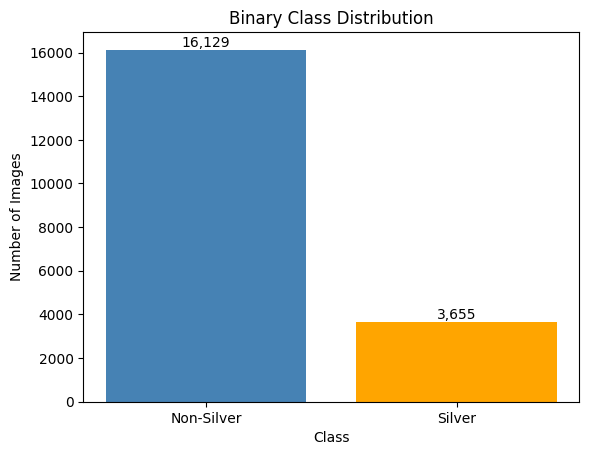

In [3]:
# Filter out images that did not get downloaded
silver_downloaded = df_silver[df_silver["label"] != "drop"]
non_silver_downloaded = df_non_silver[df_non_silver["label"] != "drop"]
# Key minerals that are silver
SILVER_WORDS = [
    "silver", "native silver", "argentum",
    "argentite", "acanthite",
    "chlorargyrite", "cerargyrite", "horn silver",
    "proustite", "pyrargyrite",
    "stephanite", "polybasite", "pearceite",
    "miargyrite", "freibergite"
]
# Convert to lowercase
SILVER_WORDS_LOWER = [w.lower() for w in SILVER_WORDS]

# Keep only silver mineral names
df_silver_only = silver_downloaded[
    silver_downloaded["mineral"]
    .fillna("")
    .str.lower()
    .str.strip()
    .isin(SILVER_WORDS_LOWER)
]

# Keep all minerals names less than 4 words, eliminates non-mineral images
df_non_silver_only = non_silver_downloaded[
    non_silver_downloaded["mineral"]
    .fillna("")
    .str.strip()
    .str.split()
    .str.len()
    .isin([1, 2, 3])
]

# True count of dataset
non_silver_count, silver_count = len(df_non_silver_only), len(df_silver_only)

# Display results
plt.figure()
# Create bars
bars = plt.bar(
    ['Non-Silver', 'Silver'],
    [non_silver_count, silver_count],
    color=['steelblue', 'orange']
)
# Descriptions
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Binary Class Distribution')
# Add count labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha='center',
        va='bottom'
    )

# Display results
print(f"\nNon-Silver Class: {non_silver_count} images")
print(f"Silver Class: {silver_count} images")

#3. Silver Class Mineral Distribution

Build a distribution plot for the Silver class mineral distribution.

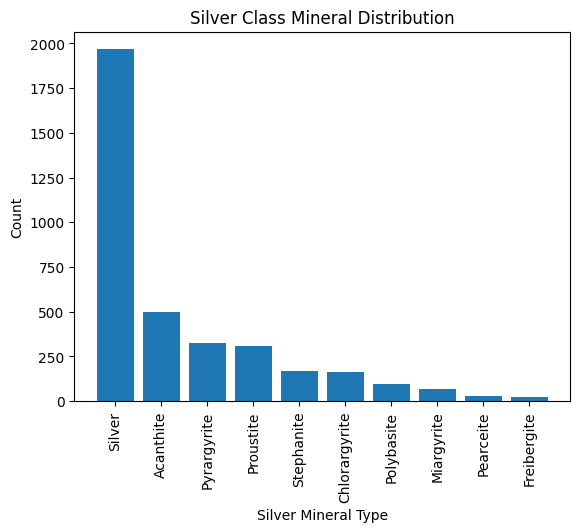

Silver Class Mineral Distribution:
mineral
Silver           1967
Acanthite         498
Pyrargyrite       325
Proustite         311
Stephanite        170
Chlorargyrite     165
Polybasite         94
Miargyrite         68
Pearceite          31
Freibergite        26
Name: count, dtype: int64


In [4]:
# Count occurrences
mineral_counts = df_silver_only["mineral"].value_counts()

# Single bar plot
plt.figure()
plt.bar(mineral_counts.index, mineral_counts.values)
plt.xticks(rotation=90)
plt.xlabel("Silver Mineral Type")
plt.ylabel("Count")
plt.title("Silver Class Mineral Distribution")
plt.show()

#display results
print("Silver Class Mineral Distribution:")
print(mineral_counts)

#4. Non-Silver Class Mineral Distribution

Build a distribution plot for the Non-ilver class mineral distribution.

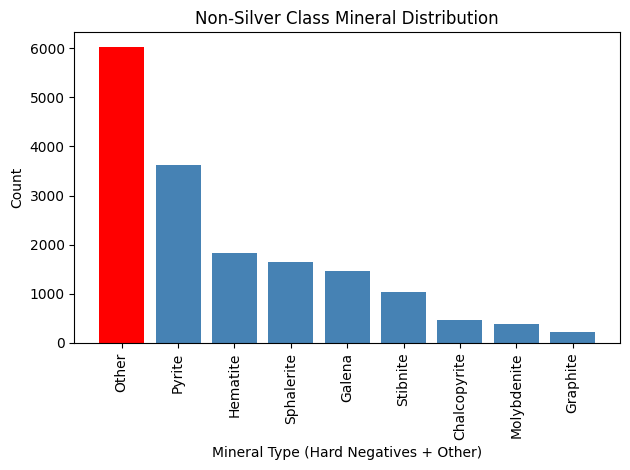

In [7]:
# Hard negatives in the Non-Silver class
HARD_NEG_WORDS = [
    "galena","pyrite","hematite","graphite",
    "stibnite","sphalerite","chalcopyrite","molybdenite"
]
HARD_NEG_WORDS_LOWER = [w.lower() for w in HARD_NEG_WORDS]

# Make sure you're filtering the SAME dataframe you're counting from
df_non = non_silver_downloaded.copy()

# Hard negatives only
df_hard_only = df_non[
    df_non["mineral"]
        .fillna("")
        .str.lower()
        .str.strip()
        .isin(HARD_NEG_WORDS_LOWER)
].copy()

# Count hard negatives
hard_counts = df_hard_only["mineral"].value_counts()

# Soft negatives ("Other") = total - hard
total_non = df_non.shape[0]
total_hard = df_hard_only.shape[0]
soft_count = total_non - total_hard

# Build final series with "Other" appended
final_counts = hard_counts.copy()
final_counts["Other"] = soft_count

# Sort for plotting
final_counts = final_counts.sort_values(ascending=False)

# Colors: red for Other, blue for hard negatives
colors = ["red" if label == "Other" else "steelblue" for label in final_counts.index]

# Plot
plt.figure()
plt.bar(final_counts.index, final_counts.values, color=colors)

plt.xticks(rotation=90)
plt.xlabel("Mineral Type (Hard Negatives + Other)")
plt.ylabel("Count")
plt.title("Non-Silver Class Mineral Distribution")
plt.tight_layout()
plt.show()

#5. Image Width Distribution for Silver and Non-silver Classes


Build a distribution plot for image width distribution for Silver and Non-silver Classes.

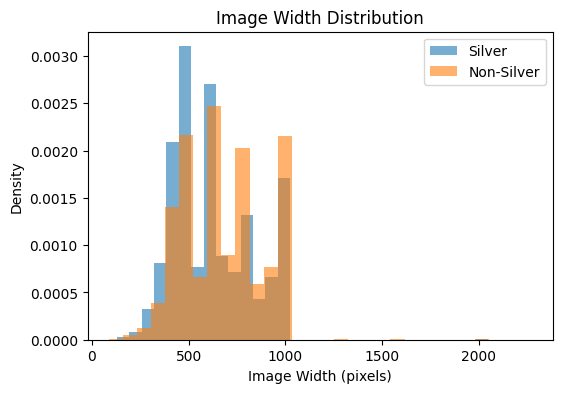

In [9]:
# Build plot
plt.figure(figsize=(6,4))
plt.hist(df_silver_only["image_width"], bins=30, density=True, alpha=0.6, label="Silver")
plt.hist(non_silver_downloaded["image_width"], bins=30, density=True, alpha=0.6, label="Non-Silver")
plt.xlabel("Image Width (pixels)")
plt.ylabel("Density")
plt.title("Image Width Distribution")
plt.legend()
plt.show()

#6. Aspect Ratio Distribution for Silver and Non-Silver Classes

Build a distribution plot for aspect ratio distribution for Silver and Non-silver Classes.

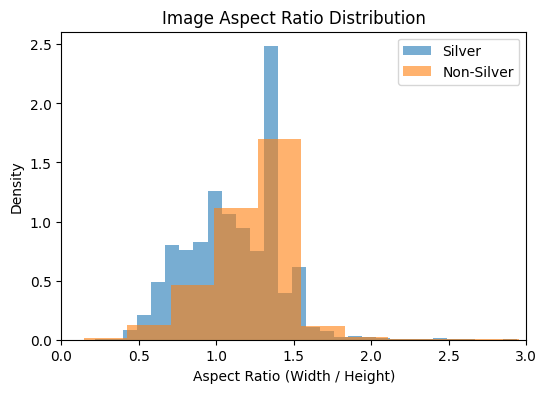

In [10]:
# Build plot
plt.figure(figsize=(6,4))
plt.hist(df_silver_only["aspect_ratio"], bins=30, density=True, alpha=0.6, label="Silver")
plt.hist(non_silver_downloaded["aspect_ratio"], bins=30, density=True, alpha=0.6, label="Non-Silver")
plt.xlim(0, 3)
plt.xlabel("Aspect Ratio (Width / Height)")
plt.ylabel("Density")
plt.title("Image Aspect Ratio Distribution")
plt.legend()
plt.show()

#7. Brightness Distribution for Silver and Non-Silver Classes

Build a distribution plot for brightness distribution for Silver and Non-silver Classes.

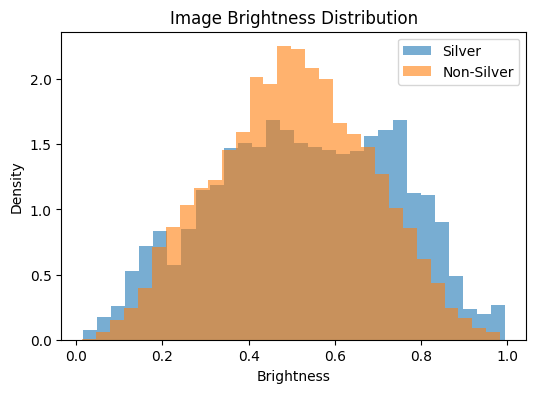

In [11]:
# Build plot
plt.figure(figsize=(6,4))
plt.hist(df_silver_only["brightness"], bins=30, density=True, alpha=0.6, label="Silver")
plt.hist(non_silver_downloaded["brightness"], bins=30, density=True, alpha=0.6, label="Non-Silver")
plt.xlabel("Brightness")
plt.ylabel("Density")
plt.title("Image Brightness Distribution")
plt.legend()
plt.show()

#8. Contrast Distribution for Silver and Non-Silver Classes

Build a distribution plot for contrast distribution for Silver and Non-silver Classes.

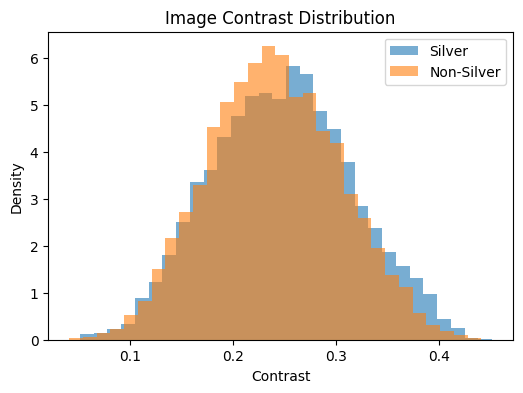

In [12]:
# Normalized Contrast Distribution Comparison
plt.figure(figsize=(6,4))
plt.hist(df_silver_only["contrast"], bins=30, density=True, alpha=0.6, label="Silver")
plt.hist(non_silver_downloaded["contrast"], bins=30, density=True, alpha=0.6, label="Non-Silver")
plt.xlabel("Contrast")
plt.ylabel("Density")
plt.title("Image Contrast Distribution")
plt.legend()
plt.show()

#9. Confirmation of data format for model input

This code loads the Silver and Non-Silver image dataset from Google Drive and splits it into training and validation sets. The images are resized to 224×224 pixels, batched, and labeled for binary classification. Pixel values are normalized to the range [0, 1], and the dataset is formatted in NHWC structure for CNN training using Keras.

In [13]:
# Dataset configuration
dataset_path = "/content/drive/MyDrive/silver_detection/dataset/"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
VAL_SPLIT = 0.2

# Load and split Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

# Validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

# Confirm class labels
class_names = train_ds.class_names
print("Class names (label order):", class_names)
print("Label mapping:", {name: i for i, name in enumerate(class_names)})

# Normalize pixel values
train_ds = train_ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y))
val_ds   = val_ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y))

# Improve performance with prefetching
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)

# Confirm tensor Shapes
for images, labels in train_ds.take(1):
    print("\nImage tensor shape:", images.shape)
    print("Image tensor dtype:", images.dtype)
    print("\nLabel tensor shape:", labels.shape)
    print("Label tensor dtype:", labels.dtype)
    # Display confirmation results
    print("\nData Format:")
    print("Image format: NHWC (Batch, Height, Width, Channels)")
    print(f"N (batch size)  = {images.shape[0]}")
    print(f"H (height)      = {images.shape[1]}")
    print(f"W (width)       = {images.shape[2]}")
    print(f"C (channels)    = {images.shape[3]}")

Found 20564 files belonging to 2 classes.
Using 16452 files for training.
Found 20564 files belonging to 2 classes.
Using 4112 files for validation.
Class names (label order): ['non_silver_images', 'silver_images']
Label mapping: {'non_silver_images': 0, 'silver_images': 1}

Image tensor shape: (32, 224, 224, 3)
Image tensor dtype: <dtype: 'float32'>

Label tensor shape: (32, 1)
Label tensor dtype: <dtype: 'float32'>

Data Format:
Image format: NHWC (Batch, Height, Width, Channels)
N (batch size)  = 32
H (height)      = 224
W (width)       = 224
C (channels)    = 3
